# **Ejemplo**

1- Definición del CSP

Una organización debe planificar la ejecución de 7 tareas:

A,B,C,D,E,F,G

Cada tarea debe ejecutarse en un instante discreto de tiempo, y existen restricciones de precedencia, incompatibilidad y dependencia entre ellas.

Cada tarea puede realizarse en ciertos momentos:

- A: {1, 2, 3}
- B: {1, 2}
- C: {2, 3}
- D: {1, 2, 3}
- E: {2, 3}
- F: {1, 2}
- G: {1, 2, 3}

Se deben cumplir las siguientes condiciones:

- A y B no pueden ejecutarse al mismo tiempo
(conflicto de recurso compartido)
- A debe ejecutarse antes que C
(precedencia)
- B y D no pueden ejecutarse al mismo tiempo
(conflicto)
- C puede ejecutarse antes o al mismo tiempo que E
- D debe ejecutarse antes que F
- E y G no pueden ejecutarse al mismo tiempo
- F debe ejecutarse antes que G

In [ ]:
!pip install networkx matplotlib


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque
import copy

In [ ]:
from collections import deque

# Definición del CSP
variables = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

domains = {
    'A': [1,2,3],
    'B': [1,2],
    'C': [2,3],
    'D': [1,2,3],
    'E': [2,3],
    'F': [1,2],
    'G': [1,2,3]
}

# Restricciones
def constraint(xi, vi, xj, vj):
    if (xi,xj) in [('A','B'),('B','A'),('B','D'),('D','B'),('E','G'),('G','E')]: # Al ser no direccionado, se incluye los dos casos: AB;BA
        return vi != vj # Develve un booleano --> se busca que si no se cumple la restricción devuelta F

    if (xi,xj) == ('A','C'):
        return vi < vj
    if (xi,xj) == ('C','A'):
        return vj < vi

    if (xi,xj) == ('C','E'):
        return vi <= vj
    if (xi,xj) == ('E','C'):
        return vj <= vi

    if (xi,xj) == ('D','F'):
        return vi < vj
    if (xi,xj) == ('F','D'):
        return vj < vi

    if (xi,xj) == ('F','G'):
        return vi < vj
    if (xi,xj) == ('G','F'):
        return vj < vi

    return True

## Grafo de vecinos

In [ ]:
# El grafo (de vecinos) se debe elaborar en función las relaciones entre los nodos/variables

neighbors = {
    'A': ['B','C'],
    'B': ['A','D'],
    'C': ['A','E'],
    'D': ['B','F'],
    'E': ['C','G'],
    'F': ['D','G'],
    'G': ['E','F']
}

## Visualización del grafo

In [ ]:
def draw_graph(domains, title=""):
    G = nx.Graph()

    for var in variables:
        G.add_node(var)

    for xi in neighbors:
        for xj in neighbors[xi]:
            if not G.has_edge(xi, xj):
                G.add_edge(xi, xj)

    pos = nx.spring_layout(G, seed=42)

    labels = {v: f"{v}\n{domains[v]}" for v in variables}

    colors = []
    for v in variables:
        if len(domains[v]) == 0:
            colors.append("red")       # inconsistente
        elif len(domains[v]) == 1:
            colors.append("lightgreen") # casi asignado
        else:
            colors.append("lightblue")  # normal

    plt.figure(figsize=(6,6))
    nx.draw(G, pos, with_labels=True, labels=labels,
            node_color=colors, node_size=2500,
            font_size=10)

    plt.title(title)
    plt.show()

## Función REVISE

In [ ]:
def revise(domains, xi, xj):
    revised = False
    to_remove = []

    for vi in domains[xi]:
        for vj in domains[xj]:
          print(xi, vi, xj, vj, constraint(xi, vi, xj, vj))
        if not any(constraint(xi, vi, xj, vj) for vj in domains[xj]): # ?
            to_remove.append(vi)

    for vi in to_remove:
        domains[xi].remove(vi) # Actualiza el dominio
        revised = True

    return revised

In [ ]:
domains

{'A': [1, 2, 3],
 'B': [1, 2],
 'C': [2, 3],
 'D': [1, 2, 3],
 'E': [2, 3],
 'F': [1, 2],
 'G': [1, 2, 3]}

In [ ]:
revise(domains, "A", "B")

A 1 B 1 False
A 1 B 2 True
A 2 B 1 True
A 2 B 2 False
A 3 B 1 True
A 3 B 2 True


False

## Implementación de AC-3 con trazas

In [ ]:
queue_test = deque()
# Inicializar cola con todos los arcos
for xi in neighbors:
  for xj in neighbors[xi]:
      queue_test.append((xi, xj))

print(queue_test)

deque([('A', 'B'), ('A', 'C'), ('B', 'A'), ('B', 'D'), ('C', 'A'), ('C', 'E'), ('D', 'B'), ('D', 'F'), ('E', 'C'), ('E', 'G'), ('F', 'D'), ('F', 'G'), ('G', 'E'), ('G', 'F')])


In [ ]:
import random
list_test = list(queue)
random.shuffle(list_test)
queue = deque(list_test)

print(queue)

deque([('C', 'E'), ('B', 'A'), ('D', 'B'), ('A', 'B'), ('A', 'C'), ('E', 'C'), ('F', 'G'), ('F', 'D'), ('B', 'D'), ('E', 'G'), ('D', 'F'), ('G', 'E'), ('C', 'A'), ('G', 'F')])


In [ ]:
def ac3(domains, neighbors):
    queue = deque()

    # Inicializar cola con todos los arcos
    for xi in neighbors:
        for xj in neighbors[xi]:
            queue.append((xi, xj))

    step = 0

    while queue:
        xi, xj = queue.popleft()
        step += 1

        print(f"\nPaso {step}: Revisando arco ({xi}, {xj})")
        #print(f"Dominios antes: {xi}={domains[xi]}, {xj}={domains[xj]}")

        if revise(domains, xi, xj):
            #print(f"⚠️ Cambio en {xi} → nuevo dominio: {domains[xi]}")

            if len(domains[xi]) == 0:
                #print(f"❌ Dominio vacío en {xi}. CSP inconsistente.")
                return False

            for xk in neighbors[xi]:
                if xk != xj:
                    queue.append((xk, xi))
                    #print(f"   ↪ Se agrega ({xk}, {xi}) a la cola")
                    print(queue)
        else:
            print("Sin cambios")

    return True

In [ ]:
# AC-3 con visualización paso a paso

def ac3_visual(domains, neighbors):
    queue = deque()

    for xi in neighbors:
        for xj in neighbors[xi]:
            queue.append((xi, xj))

    step = 0
    draw_graph(domains, "Estado inicial")

    while queue:
        xi, xj = queue.popleft()
        step += 1

        print(f"\nPaso {step}: ({xi}, {xj})")

        before = copy.deepcopy(domains)

        if revise(domains, xi, xj):
            print(f"Cambio en {xi}: {before[xi]} → {domains[xi]}")

            draw_graph(domains, f"Paso {step}: cambio en {xi}")

            if len(domains[xi]) == 0:
                print(f"\n❌ Dominio vacío en {xi}")
                draw_graph(domains, "INCONSISTENTE")
                return False

            for xk in neighbors[xi]:
                if xk != xj:
                    queue.append((xk, xi))
        else:
            print("Sin cambios")

    return True

## Ejecución

In [ ]:
import copy

domains_copy = copy.deepcopy(domains)

result = ac3(domains_copy, neighbors)

print("\n========================")
print("RESULTADO FINAL")
print("========================")

if result:
    print("✅ CSP consistente")
else:
    print("❌ CSP inconsistente")

print("\nDominios finales:")
for var in domains_copy:
    print(f"{var}: {domains_copy[var]}")


Paso 1: Revisando arco (A, B)
A 1 B 1 False
A 1 B 2 True
A 2 B 1 True
A 2 B 2 False
A 3 B 1 True
A 3 B 2 True
Sin cambios

Paso 2: Revisando arco (A, C)
A 1 C 2 True
A 1 C 3 True
A 2 C 2 False
A 2 C 3 True
A 3 C 2 False
A 3 C 3 False
deque([('B', 'A'), ('B', 'D'), ('C', 'A'), ('C', 'E'), ('D', 'B'), ('D', 'F'), ('E', 'C'), ('E', 'G'), ('F', 'D'), ('F', 'G'), ('G', 'E'), ('G', 'F'), ('B', 'A')])

Paso 3: Revisando arco (B, A)
B 1 A 1 False
B 1 A 2 True
B 2 A 1 True
B 2 A 2 False
Sin cambios

Paso 4: Revisando arco (B, D)
B 1 D 1 False
B 1 D 2 True
B 1 D 3 True
B 2 D 1 True
B 2 D 2 False
B 2 D 3 True
Sin cambios

Paso 5: Revisando arco (C, A)
C 2 A 1 True
C 2 A 2 False
C 3 A 1 True
C 3 A 2 True
Sin cambios

Paso 6: Revisando arco (C, E)
C 2 E 2 True
C 2 E 3 True
C 3 E 2 False
C 3 E 3 True
Sin cambios

Paso 7: Revisando arco (D, B)
D 1 B 1 False
D 1 B 2 True
D 2 B 1 True
D 2 B 2 False
D 3 B 1 True
D 3 B 2 True
Sin cambios

Paso 8: Revisando arco (D, F)
D 1 F 1 False
D 1 F 2 True
D 2 F 1 

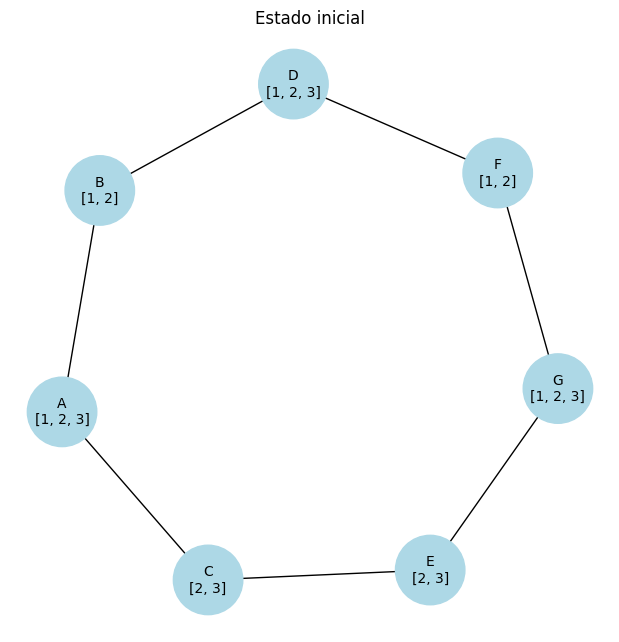


Paso 1: (A, B)
Sin cambios

Paso 2: (A, C)
Cambio en A: [1, 2, 3] → [1, 2]


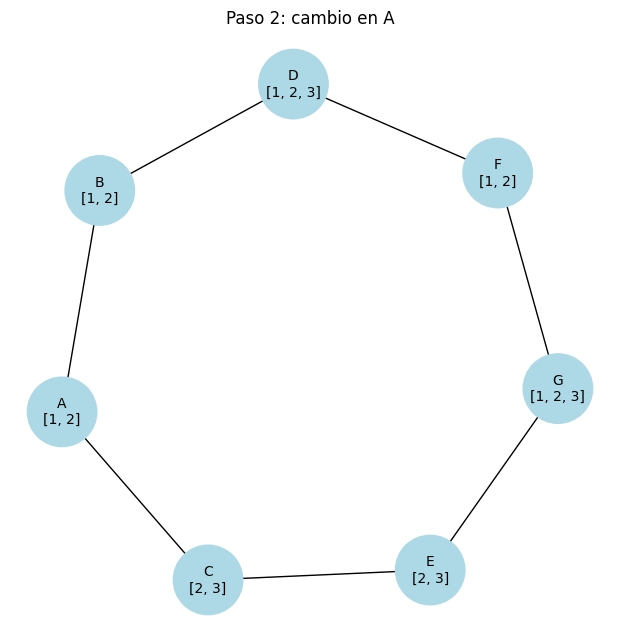


Paso 3: (B, A)
Sin cambios

Paso 4: (B, D)
Sin cambios

Paso 5: (C, A)
Sin cambios

Paso 6: (C, E)
Sin cambios

Paso 7: (D, B)
Sin cambios

Paso 8: (D, F)
Cambio en D: [1, 2, 3] → [1]


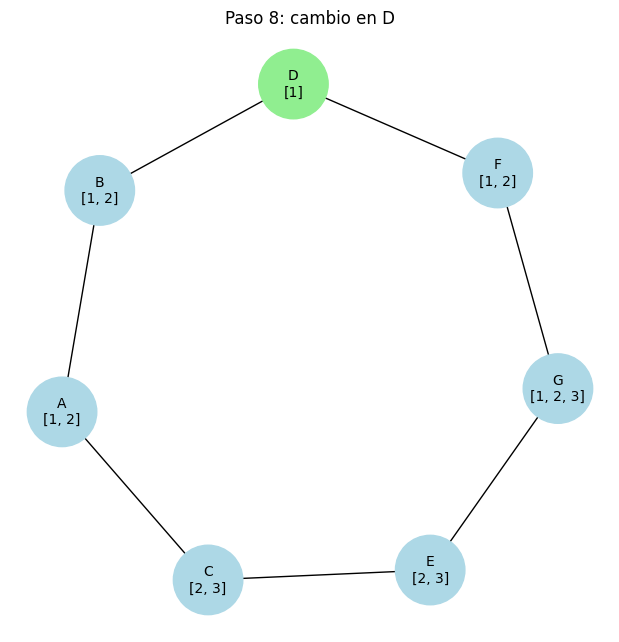


Paso 9: (E, C)
Sin cambios

Paso 10: (E, G)
Sin cambios

Paso 11: (F, D)
Cambio en F: [1, 2] → [2]


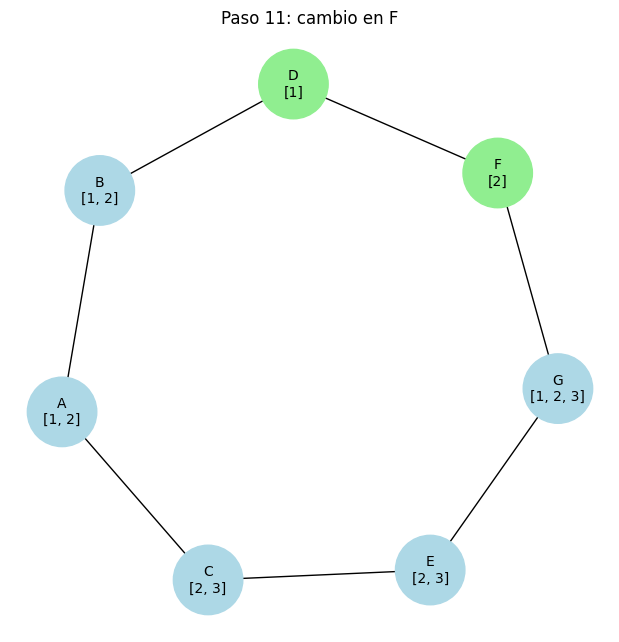


Paso 12: (F, G)
Sin cambios

Paso 13: (G, E)
Sin cambios

Paso 14: (G, F)
Cambio en G: [1, 2, 3] → [3]


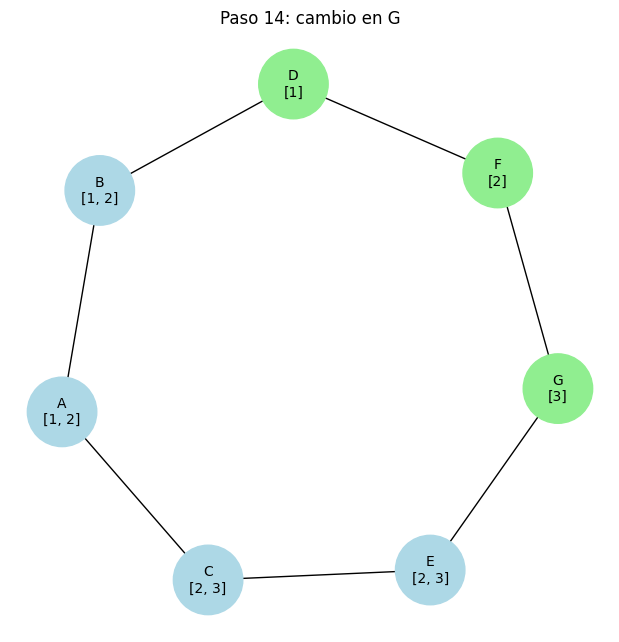


Paso 15: (B, A)
Sin cambios

Paso 16: (B, D)
Cambio en B: [1, 2] → [2]


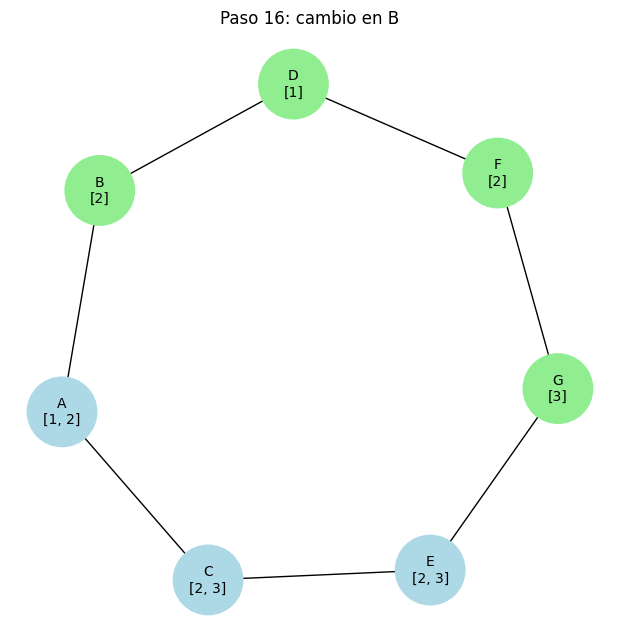


Paso 17: (G, F)
Sin cambios

Paso 18: (E, G)
Cambio en E: [2, 3] → [2]


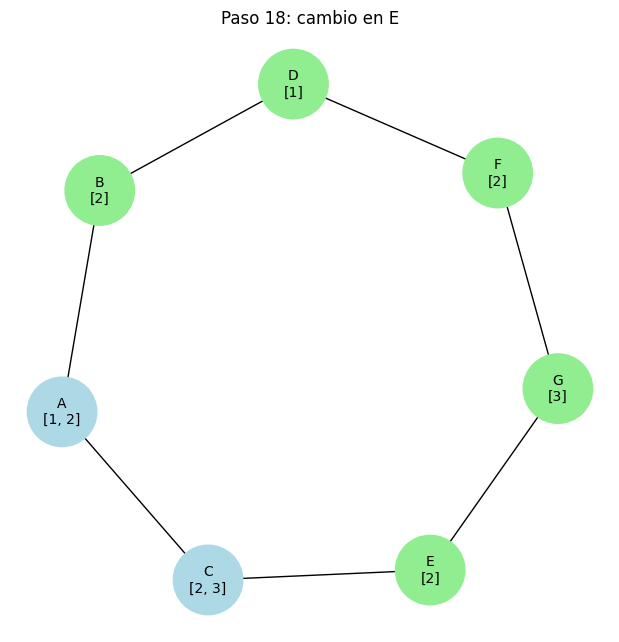


Paso 19: (A, B)
Cambio en A: [1, 2] → [1]


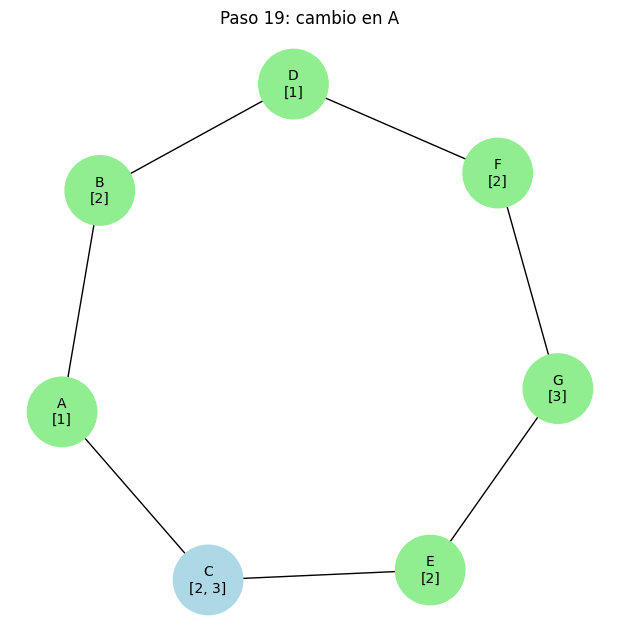


Paso 20: (C, E)
Cambio en C: [2, 3] → [2]


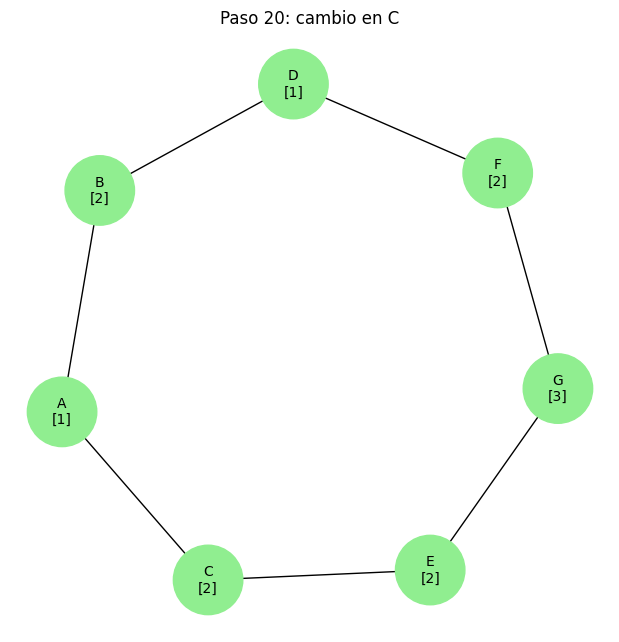


Paso 21: (C, A)
Sin cambios

Paso 22: (A, C)
Sin cambios

Resultado final:
Consistente: True


In [ ]:
# Lo mismo que antes pero "visual"
domains_copy = copy.deepcopy(domains)

result = ac3_visual(domains_copy, neighbors)

print("\nResultado final:")
print("Consistente:", result)

# ***Volvemos a la filmina***

# CSP — Constraint Satisfaction Problems
(Con heurísticas + métricas + análisis empírico)

## 1. Definición

Trabajaremos con un CSP de coloreo de grafos con 10 variables.


In [ ]:
import time
import networkx as nx
import matplotlib.pyplot as plt


In [ ]:
variables = ['A','B','C','D','E','F','G','H','I','J']

domains = {v: ['Rojo','Verde','Azul'] for v in variables}

constraints = {
    ('A','B'),('A','C'),
    ('B','D'),('B','E'),
    ('C','F'),('C','G'),
    ('D','H'),('E','H'),
    ('F','I'),('G','I'),
    ('H','J'),('I','J')
}


## Visualización del grafo

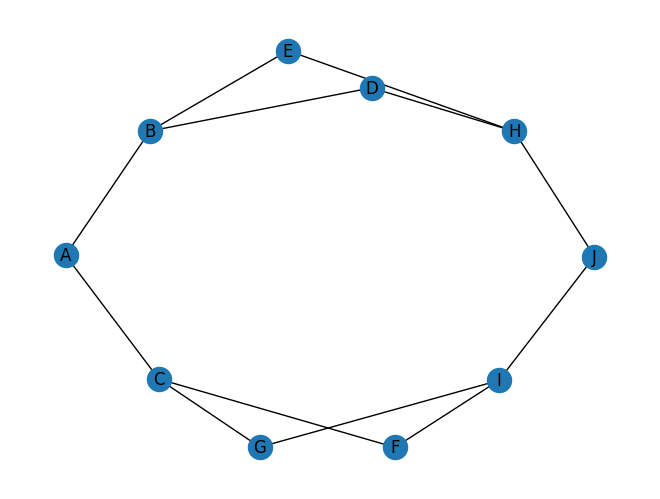

In [ ]:
G = nx.Graph()
G.add_nodes_from(variables)
G.add_edges_from(constraints)
pos = nx.spring_layout(G, seed=142)
domains_base = {v: ['Rojo','Verde','Azul'] for v in variables}

nx.draw(G, pos, with_labels=True)
plt.show()

## 2. Funciones base

In [ ]:
def is_valid(assignment, var, value):
    for (x,y) in constraints:
        if x == var and y in assignment and assignment[y] == value:
            return False
        if y == var and x in assignment and assignment[x] == value:
            return False
    return True

## 3. Heurísticas

In [ ]:
# MRV (Minimum Remaining Values)
def select_mrv(assignment, domains):
    unassigned = [v for v in variables if v not in assignment]
    return min(unassigned, key=lambda var: len(domains[var]))

# Degree heuristic
def select_degree(assignment):
    unassigned = [v for v in variables if v not in assignment]
    return max(unassigned, key=lambda var: len([1 for (x,y) in constraints if x==var or y==var]))

# LCV (Least Constraining Value)
def order_lcv(var, domains):
    def count_constraints(value):
        count = 0
        for (x,y) in constraints:
            if x == var and y in domains:
                count += domains[y].count(value)
        return count
    return sorted(domains[var], key=count_constraints)


## 4. Backtracking con heurísticas

In [ ]:
def backtracking(assignment, domains, use_mrv=True):
    global nodes_explored
    nodes_explored += 1

    if len(assignment) == len(variables):
        return assignment

    if use_mrv:
        var = select_mrv(assignment, domains)
    else:
        var = next(v for v in variables if v not in assignment)

    for value in order_lcv(var, domains):
        if is_valid(assignment, var, value):
            assignment[var] = value
            result = backtracking(assignment, domains, use_mrv)
            if result:
                return result
            del assignment[var]

    return None

## 5. Forward Checking + heurísticas

In [ ]:
def forward_checking(assignment, domains):
    global nodes_explored
    nodes_explored += 1

    if len(assignment) == len(variables):
        return assignment

    var = select_mrv(assignment, domains)

    for value in order_lcv(var, domains):
        if is_valid(assignment, var, value):
            local_domains = {v:list(domains[v]) for v in domains}
            assignment[var] = value

            for (x,y) in constraints:
                if x == var and y not in assignment:
                    local_domains[y] = [v for v in local_domains[y] if v != value]

            result = forward_checking(assignment, local_domains)
            if result:
                return result

            del assignment[var]

    return None

## 6. Experimentos y métricas

In [ ]:
def run_experiment(method):
    global nodes_explored
    nodes_explored = 0
    domains = {v:list(domains_base[v]) for v in variables}

    start = time.time()

    if method == 'BT':
        sol = backtracking({}, domains, use_mrv=False)
    elif method == 'BT+MRV':
        sol = backtracking({}, domains, use_mrv=True)
    elif method == 'FC':
        sol = forward_checking({}, domains)

    end = time.time()

    return {
        'method': method,
        'time': end - start,
        'nodes': nodes_explored,
        'solution': sol
    }

results = [
    run_experiment('BT'),
    run_experiment('BT+MRV'),
    run_experiment('FC')
]

for r in results:
    print(r['method'], "→ tiempo:", r['time'], "nodos:", r['nodes'])

BT → tiempo: 0.0001246929168701172 nodos: 11
BT+MRV → tiempo: 0.00010538101196289062 nodos: 11
FC → tiempo: 0.00016689300537109375 nodos: 11


## 7. Visualización de métricas

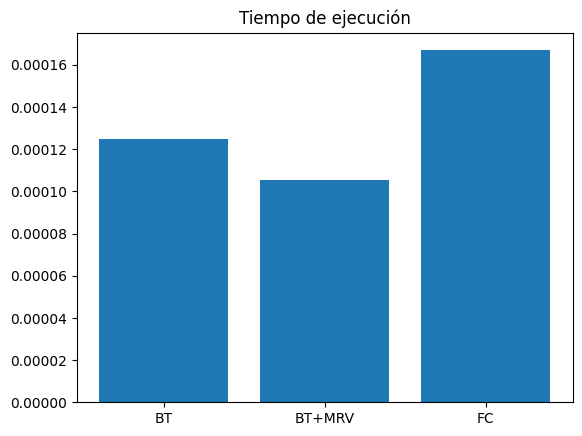

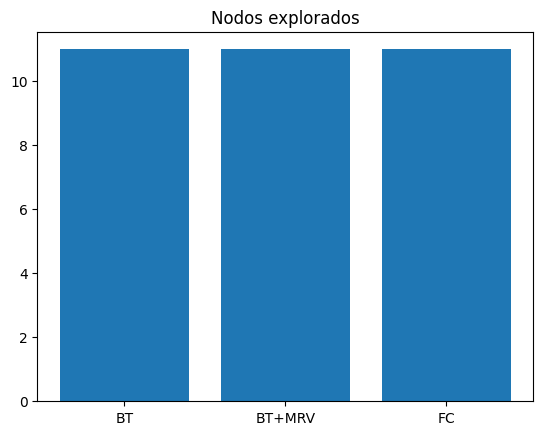

In [ ]:
methods = [r['method'] for r in results]
times = [r['time'] for r in results]
nodes = [r['nodes'] for r in results]

plt.figure()
plt.bar(methods, times)
plt.title("Tiempo de ejecución")
plt.show()

plt.figure()
plt.bar(methods, nodes)
plt.title("Nodos explorados")
plt.show()


## 8. Visualización de solución

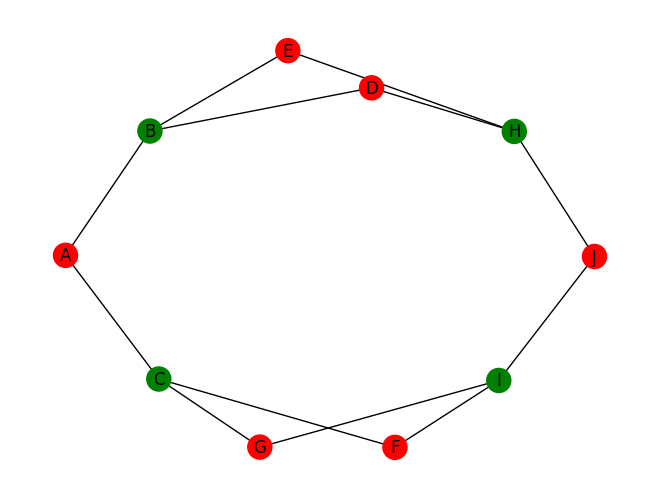

In [ ]:
def visualize_solution(solution):
    color_map = {'Rojo':'red','Verde':'green','Azul':'blue'}
    node_colors = [color_map[solution[n]] for n in G.nodes()]
    nx.draw(G, pos, with_labels=True, node_color=node_colors)
    plt.show()

visualize_solution(results[2]['solution'])

## 9. Conclusiones

- MRV reduce branching factor
- LCV reduce conflictos futuros
- Forward Checking poda tempranamente
- Combinación → mejora drástica

👉 Esto es la base de sistemas reales de scheduling

---

## 10. Ejercicios

1. Implementar AC-3 + FC
2. Comparar con 15+ nodos
3. Generar instancias aleatorias
4. Analizar complejidad empírica
5. Aplicar a horarios universitarios reales
